In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import qnmfits
import utils

from cmcrameri import cm

plt.rcParams.update(utils.rcparams)

In [2]:
t0_E = pd.read_csv('../data/t0N_E.csv', index_col=0)

In [3]:
ID = 1
sim_info = utils.load_cce_data(ID)
sim = sim_info['sim']
chif = sim.chif_mag
Mf = sim.Mf

In [4]:
sim_info_lev4 = utils.load_cce_data(ID, lev=4)
sim_lev4 = sim_info_lev4['sim']
chif_lev4 = sim_lev4.chif_mag
Mf_lev4 = sim_lev4.Mf

In [5]:
epsilon_NR = np.sqrt((Mf - Mf_lev4)**2 + (chif - chif_lev4)**2)
epsilon_NR

np.float64(5.916995288981202e-06)

In [6]:
sigma_Mf = np.abs(Mf - Mf_lev4)
sigma_chif = np.abs(chif - chif_lev4)

sigma_Mf, sigma_chif

(np.float64(2.206820615135996e-07), np.float64(5.912878544123146e-06))

In [7]:
t0 = t0_E[str(ID)].values[10]
t0

np.float64(-1.87500921076753)

In [8]:
N = 13
modes = [(2, 2, n, 1) for n in range(N+1)] + [(3,2,0,1)]

In [9]:
epsilon_zero = qnmfits.calculate_epsilon(
    sim.times,
    sim.h[2,2],
    modes,
    Mf,
    chif,
    t0=t0,
    t0_method='closest',
)[0]

In [10]:
delta_list_dense = np.linspace(-0.2, 0.2, 20)
ntilde = 7
epsilon_grid = np.zeros((len(delta_list_dense), len(delta_list_dense)))

for i, delta_i in enumerate(delta_list_dense[::-1]):
    for j, delta_r in enumerate(delta_list_dense):
        frequency_deltas_r = np.zeros(len(modes))
        frequency_deltas_i = np.zeros(len(modes))
        frequency_deltas_r[ntilde] = delta_r
        frequency_deltas_i[ntilde] = delta_i
        # frequency_deltas_r = delta_r * np.ones(len(modes))
        # frequency_deltas_i = delta_i * np.ones(len(modes))
        # frequency_deltas_r[:5] = 0
        # frequency_deltas_i[:5] = 0
        epsilon, Mf_bestfit, chif_bestfit = qnmfits.calculate_epsilon(
            times=sim.times,
            data=sim.h[2,2], 
            modes=modes,
            Mf=sim.Mf, 
            chif=sim.chif_mag, 
            t0=t0,
            t0_method='closest',
            T=100,
            delta_r=frequency_deltas_r,
            delta_i=frequency_deltas_i
        )
        epsilon_grid[i, j] = epsilon
        # delta_Mf = Mf_bestfit - Mf
        # delta_chif = chif_bestfit - chif
        # epsilon_grid[i, j] = np.sqrt((delta_Mf/sigma_Mf)**2 + (delta_chif/sigma_chif)**2)

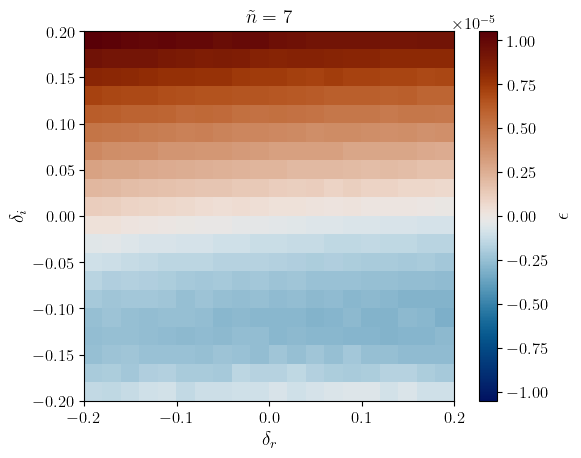

In [11]:
fig, ax = plt.subplots()
plot_values = epsilon_grid - epsilon_zero 
# (epsilon_grid - epsilon_zero)/epsilon_NR
ax.imshow(
    plot_values, 
    extent=(
        delta_list_dense[0],
        delta_list_dense[-1],
        delta_list_dense[0],
        delta_list_dense[-1]
    ),
    aspect='equal',
    cmap=cm.vik,
    vmax=np.max(abs(plot_values)),
    vmin=-np.max(abs(plot_values))
)
ax.set_xlabel(r'$\delta_r$')
ax.set_ylabel(r'$\delta_i$')
ax.set_title(rf'$\tilde{{n}} = {ntilde}$')

cbar = fig.colorbar(ax.images[0], ax=ax)
cbar.set_label(r'$\epsilon$')

fig.savefig(
    f"figures/frequency_perturbations/epsilon_tilde_{ntilde}.png",
    dpi=300,
    bbox_inches='tight'
)